In [ ]:
import torch
device = torch.device('cuda')
print(device)

cuda


In [16]:
#Relu ACTIVATION FUNCTION
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device = device))


#SIGMOID ACTIVATION FUNCTION
def sigmoid(x):
    return 1/1 + (torch.exp(-x))

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
device = torch.device('cuda')
train_data  = datasets.MNIST(train= True, root = 'data' , transform = ToTensor(), download= False)

train_data

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2+cu118
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

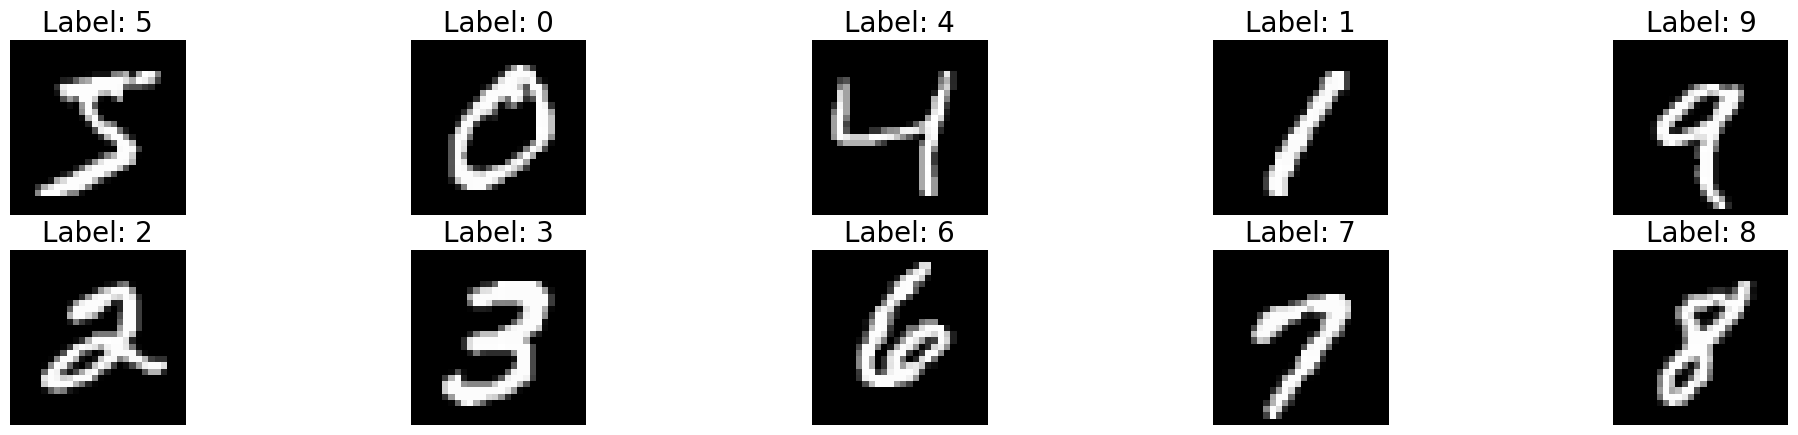

In [ ]:
import matplotlib.pyplot as plt
fig , ax = plt.subplots(2, 5 , figsize = (25, 5) )
r = 0
c = 0
label = []
i=0
while len(label)< 10:
    x, y = train_data[i]
    if y not in label:
       label.append(y)
       if c == 4:
            ax[r , c].imshow(x.squeeze(), cmap = "grey")
            ax[r , c].set_title(f"Label: {y}" , size = 20)
            ax[r, c].axis("off")
            c = 0
            r = 1
       else: 
            ax[r , c].imshow(x.squeeze(), cmap = "grey")
            ax[r , c].set_title(f"Label: {y}" , size = 20)
            ax[r, c].axis("off")
            c += 1
    i += 1
    


In [14]:
from torch.nn import functional as F
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(7)
W1 = torch.tensor(torch.randn([784 , 128], device = device)*0.01)
B1 = torch.tensor(torch.zeros([1,  128], device = device))
W2 = torch.tensor(torch.randn([128, 10], device = device)*0.01)
B2 = torch.tensor(torch.zeros([1,  10], device = device))

learning_rate = 0.01

num_epocs = 15
for i in range(num_epocs):
    correct = 0
    total = 0 
    for data in tqdm(range(len(train_data)), desc = f" EPOCH : {i+1}"):
        X, Y = train_data[data]
        X = X.to(device)
        Target = Y
        X = X.flatten()
        X = X.reshape(1, 784) 
        first_layer =  torch.mm(X , W1) + B1
        relu_activate = F.relu(first_layer)
        second_layer = torch.mm(relu_activate, W2) + B2
        probablity = F.softmax(second_layer , dim = 1)
        prediction = torch.argmax(probablity , dim = 1)
        correct_probablity = probablity[0, Target]

        correct += (prediction == Target).item()
        total += 1

        loss = -torch.log(correct_probablity)
        gradient_output = probablity.clone()
        gradient_output[0, Target] -= 1
        gradient_W2 = torch.mm(relu_activate.T , gradient_output)
        gradient_B2 = gradient_output
        gradient_H = torch.mm(gradient_output, W2.T)
        gradient_Z1 = gradient_H * (first_layer > 0)
        gradient_W1 = torch.mm(X.T, gradient_Z1)
        gradient_B1 = gradient_Z1
        
        W1 = W1 - (learning_rate * gradient_W1)
        B1 = B1 - (learning_rate * gradient_B1)

        W2 = W2 - (learning_rate * gradient_W2)
        B2 = B2 - (learning_rate * gradient_B2)
    accuracy =( correct/total) * 100
    print("ACCURACY : ", round(accuracy , 2))

    

 EPOCH : 1: 100%|██████████| 60000/60000 [04:25<00:00, 225.79it/s]


ACCURACY :  92.61


 EPOCH : 2: 100%|██████████| 60000/60000 [04:31<00:00, 220.95it/s]


ACCURACY :  97.02


 EPOCH : 3: 100%|██████████| 60000/60000 [06:04<00:00, 164.68it/s]


...

ACCURACY :  99.93


 EPOCH : 14: 100%|██████████| 60000/60000 [03:44<00:00, 267.60it/s]


ACCURACY :  99.97


 EPOCH : 15: 100%|██████████| 60000/60000 [03:45<00:00, 266.37it/s]

ACCURACY :  99.98


In [15]:
torch.save({
    "epoch":5,
    "accuracy": accuracy,
    "W1":W1,
    "B1":B1,
    "W2": W2,
    "B2": B2},
    "mnist_fcnn.pth"
)

In [16]:
checkpoint = torch.load("mnist_fcnn.pth", map_location = device)
w1 = torch.empty(784, 128 , device = device)
b1 = torch.empty(1, 128, device = device)
w2 = torch.empty(128 , 10 , device = device)
b2 = torch.empty(1, 10, device = device)

w1 = checkpoint['W1']
b1 = checkpoint['B1']
w2 = checkpoint['W2']
b2 = checkpoint['B2']
print("Trained Accuracy")
print(round(checkpoint['accuracy'], 2))

Trained Accuracy
99.98


In [17]:
from torchvision import datasets
from torchvision.transforms import ToTensor
test_data = datasets.MNIST(
    root = "data",
    train = False,
    download= False,
    transform= ToTensor()
)

In [ ]:
correct = 0
total = 0

for i in tqdm(range(len(test_data)), desc= f"Testing.."):

    X, Target = test_data[i]

    X = X.to(device)
    X = X.flatten()
    X = X.reshape(1, 784)

    # -------------------------
    # FORWARD PASS ONLY
    # -------------------------

    first_layer = torch.mm(X, w1) + b1

    relu_activate = F.relu(first_layer)

    second_layer = torch.mm(relu_activate, w2) + b2

    probability = F.softmax(second_layer, dim=1)

    prediction = torch.argmax(probability, dim=1)

    # -------------------------
    # CHECK PREDICTION
    # -------------------------

    correct += (prediction == Target).item()
    total += 1
    
accuracy = (correct / total) * 100

print("TEST ACCURACY:", round(accuracy, 2), "%")

Testing..: 100%|██████████| 10000/10000 [00:25<00:00, 397.03it/s]

TEST ACCURACY: 98.06 %
